In [4]:
import gzip
import os
import tqdm
import glob
import scanpy as sc
import pandas as pd

### Load brain single cell data

In [5]:
file_list = glob.glob("./data/GSE67835_RAW/*.csv.gz")

In [6]:
count_dfs = []
for fname in tqdm.tqdm(file_list):
    with gzip.open(fname, "rt") as f:
        df = pd.read_csv(
            f,
            sep="\t",
            index_col=0,
            header=None,
            names=[os.path.split(fname)[1]],
            skipfooter=3,
            engine="python",
        )
        df.index = df.index.str.rstrip(" ")
        count_dfs.append(df)

100%|██████████| 466/466 [00:25<00:00, 18.02it/s]


In [7]:
import anndata

adata = anndata.AnnData(
    pd.concat(
        count_dfs,
        axis=1,
        join="inner",
        verify_integrity=True,
    ).T
)

In [8]:
adata

AnnData object with n_obs × n_vars = 466 × 22085

In [9]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [10]:
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=100)

In [11]:
adata

AnnData object with n_obs × n_vars = 466 × 19550
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [12]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [13]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

In [14]:
sc.tl.pca(adata)

In [15]:
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,n_genes
GSM1658183_nochipID8.C96.csv.gz,4270,8.359603,758790,13.539482,18.455436,27.182488,39.838295,62.796294,4258
GSM1657991_1772078237.C92.csv.gz,3581,8.183677,505435,13.133177,19.959639,30.296279,44.267809,68.936263,3579
GSM1658106_nochipID3.C72.csv.gz,4135,8.327484,634147,13.360038,16.404556,25.634277,39.011459,63.418261,4134
GSM1657917_1772078218.C48.csv.gz,4464,8.404024,522416,13.166221,20.951885,31.529662,46.461249,70.166304,4461
GSM1658235_nochipID11.C15.csv.gz,2974,7.997999,740203,13.514681,22.447085,32.016217,46.035479,71.256939,2963
...,...,...,...,...,...,...,...,...,...
GSM1658016_nochipID2.C14.csv.gz,4214,8.346405,886982,13.695581,24.103871,33.231452,45.980076,68.235207,4210
GSM1658180_nochipID8.C90.csv.gz,3534,8.170469,823038,13.620759,27.429110,37.370085,50.315052,73.063334,3531
GSM1658078_nochipID2.C87.csv.gz,5310,8.577535,831524,13.631017,23.278943,30.537784,40.363237,58.694638,5309
GSM1658176_nochipID8.C84.csv.gz,6777,8.821437,517729,13.157209,14.706729,20.690168,29.537268,47.265075,6771


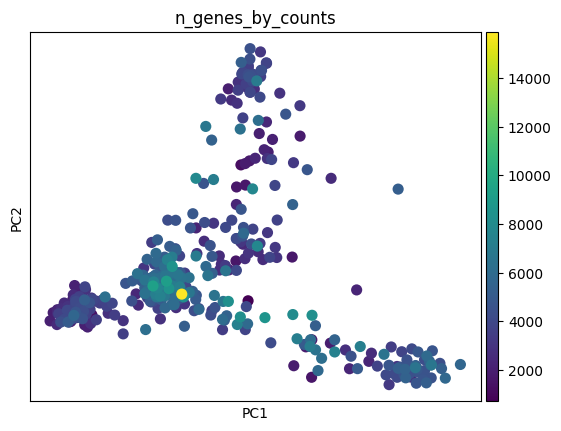

In [16]:
sc.pl.pca(adata, color="n_genes_by_counts")

In [17]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [66]:
sc.tl.leiden(adata, resolution=0.5)

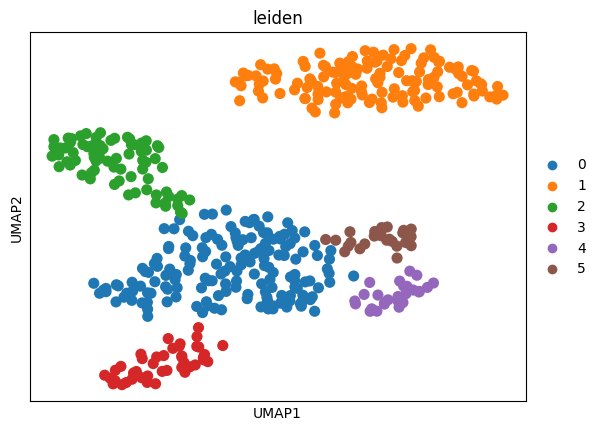

In [67]:
sc.pl.umap(adata, color="leiden")

In [68]:
adata.var.index

Index(['1/2-SBSRNA4', 'A1BG', 'A1BG-AS1', 'A1CF', 'A2LD1', 'A2M', 'A2ML1',
       'A2MP1', 'A4GALT', 'A4GNT',
       ...
       'ZWINT', 'ZXDA', 'ZXDB', 'ZXDC', 'ZYG11A', 'ZYG11B', 'ZYX', 'ZZEF1',
       'ZZZ3', 'tAKR'],
      dtype='object', length=19550)

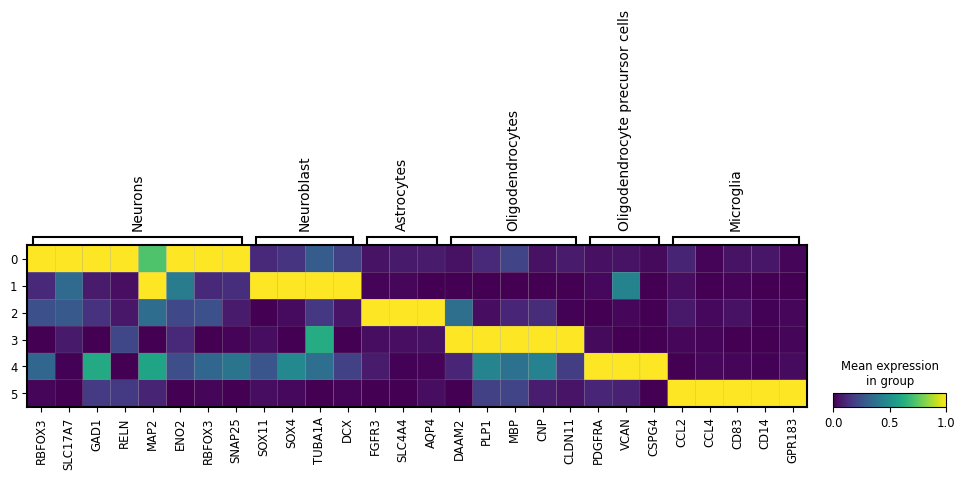

In [74]:
sc.pl.matrixplot(
    adata,
    var_names={
        "Neurons": [
            "RBFOX3",
            "SLC17A7",
            "GAD1",
            "RELN",
            "MAP2",
            "ENO2",
            "RBFOX3",
            "SNAP25",
        ],
        "Neuroblast": [
            "SOX11",
            "SOX4",
            "TUBA1A",
            "DCX",
            # "MAP1B",
            # "CD24",
            # "NNAT",
            # "STMN1",
            # "BCL11A",
            # "MEX3A",
        ],
        "Astrocytes": [
            "FGFR3",
            "SLC4A4",
            "AQP4",
        ],
        "Oligodendrocytes": [
            "DAAM2",
            "PLP1",
            "MBP",
            "CNP",
            "CLDN11",
        ],
        "Oligodendrocyte precursor cells": [
            "PDGFRA",
            "VCAN",
            "CSPG4",
        ],
        "Microglia": [
            "CCL2",
            "CCL4",
            "CD83",
            "CD14",
            "GPR183",
        ],
        # "Endothelial cells": [
        #     "FLT1",
        #     "APOLD1",
        #     "A2M",
        # ],
    },
    groupby="leiden",
    standard_scale="var",
)

In [75]:
annotation_dict = {
    "0": "Neurons",
    "1": "Neuroblast",
    "2": "Astrocytes",
    "3": "Oligodendrocytes",
    "4": "Oligodendrocyte precursor cells",
    "5": "Microglia",
}
adata.obs["cell_type"] = adata.obs["leiden"].map(annotation_dict).astype("category")

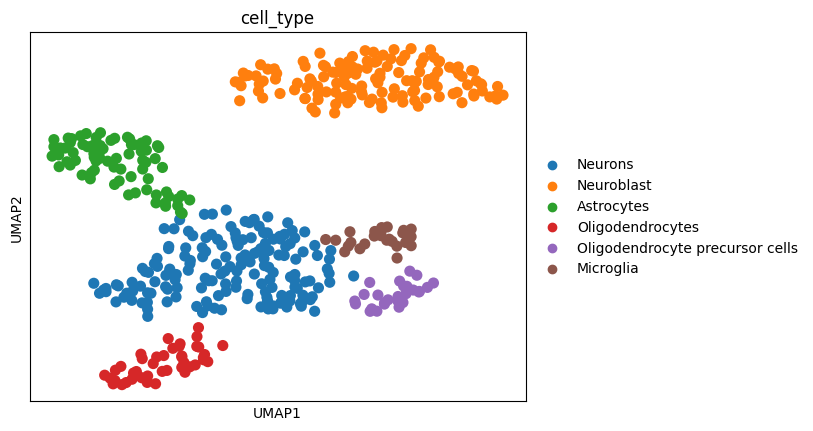

In [76]:
sc.pl.umap(adata, color="cell_type")

In [77]:
adata.write_h5ad("./data/brain_single_cell.h5ad")